<a href="https://colab.research.google.com/github/Xushnudbek76/computer-vision/blob/main/menu_image_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset
import os
import numpy as np
from torchvision.models import mobilenetv2
import torch.nn as nn
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.models import mobilenet_v2
import torch.optim as optim

In [5]:
from google.colab import drive

In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
DATASET_PATH = "/content/drive/MyDrive/food-dataset"
CUSTOM_CLASS_MAPPING = {
    "hot_dog": "hot_dog",
    "chocolate_cake": "dessert",
    "cheesecake": "dessert",
    "kebab": "kebab",
}

CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [8]:
class FoodDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path)
            if image.mode == "P" or image.mode == "RGBA":
                image = image.convert("RGB")
            else:
                    image = image.convert("RGB")
        except (UnidentifiedImageError, OSError):
            return self.__getitem__((idx + 1) % len(self.images))
        if self.transform:
            image = self.transform(image)
        return image, label

In [9]:
all_images = []
for original_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
    class_path = os.path.join(DATASET_PATH, original_class)
    print('class_path:', class_path)
    if not os.path.exists(class_path):
        print(f"Warning: {class_path} not found")
        continue
    for img in os.listdir(class_path):
        if img.endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(class_path, img)
            all_images.append((full_path, CLASS_TO_IDX[mapped_class]))

np.random.shuffle(all_images)
split = int(0.8 * len(all_images))
train_data = all_images[:split]
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

print('all_images:', all_images)

dataset = FoodDataset(train_images, train_labels)
print(len(dataset))
img, lbl = dataset[0]

class_path: /content/drive/MyDrive/food-dataset/hot_dog
class_path: /content/drive/MyDrive/food-dataset/chocolate_cake
class_path: /content/drive/MyDrive/food-dataset/cheesecake
class_path: /content/drive/MyDrive/food-dataset/kebab
all_images: [('/content/drive/MyDrive/food-dataset/hot_dog/803307.jpg', 1), ('/content/drive/MyDrive/food-dataset/chocolate_cake/1007412.jpg', 2), ('/content/drive/MyDrive/food-dataset/chocolate_cake/2280445.jpg', 2), ('/content/drive/MyDrive/food-dataset/hot_dog/1251173.jpg', 1), ('/content/drive/MyDrive/food-dataset/hot_dog/701763.jpg', 1), ('/content/drive/MyDrive/food-dataset/hot_dog/707784.jpg', 1), ('/content/drive/MyDrive/food-dataset/hot_dog/1687745.jpg', 1), ('/content/drive/MyDrive/food-dataset/chocolate_cake/2372754.jpg', 2), ('/content/drive/MyDrive/food-dataset/hot_dog/207291.jpg', 1), ('/content/drive/MyDrive/food-dataset/cheesecake/3267121.jpg', 2), ('/content/drive/MyDrive/food-dataset/chocolate_cake/3575528.jpg', 2), ('/content/drive/MyDrive

In [10]:
train_dataset = FoodDataset(train_images, train_labels, transform=transform)
val_dataset = FoodDataset(val_images, val_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# pretrained model
model = mobilenet_v2(weights="IMAGENET1K_V1")  # pretrained model | lightweight | CNN
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)  # fine-tune head

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 117MB/s] 


device cuda


In [11]:
criterion = nn.CrossEntropyLoss()  # Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001)
torch.backends.cudnn.benchmark = True  # Benchmark Setting

In [12]:
NUM_EPOCHS = 10
best_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {running_loss / len(train_loader)}")

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), "/content/menu_detector.pth")
#

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10, Loss: 0.31188603929984265
Validation Accuracy: 92.42%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2/10, Loss: 0.15601347084754172
Validation Accuracy: 91.77%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch 8/10, Loss: 0.0636347918293606
Validation Accuracy: 94.03%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 9/10, Loss: 0.06254809177092586
Validation Accuracy: 94.03%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10/10, Loss: 0.047961026458487585
Validation Accuracy: 94.68%


device: cuda
Upload one or more images of hamburger or hot dog:


Saving shashlik.jpeg to shashlik.jpeg


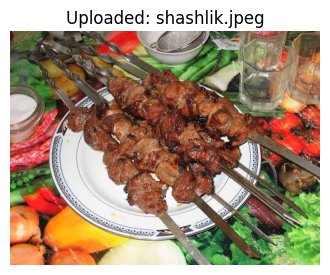

Prediction:
  ✅ hot_dog: 88.91%
  ✅ dessert: 11.03%
  ✅ kebab: 0.04%
  ✅ pilaf: 0.02%


In [18]:
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt

# ------------------------------------------------
# Define Semantic Classes
# ------------------------------------------------
CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
  # Must match training order
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}

# ------------------------------------------------
# Transform for Uploaded Images (no augmentations!)
# ------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# ------------------------------------------------
# Load Model
# ------------------------------------------------
model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/menu_detector.pth', map_location='cpu'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
model = model.to(device)
model.eval()


print("Upload one or more images of hamburger or hot dog:")
uploaded = files.upload()

for image_name in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Uploaded: {image_name}')
    plt.show()

    # Predict
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        topk = torch.topk(probs, 4)

    print("Prediction:")
    for i in range(topk.indices.size(0)):
        label = CLASSES[topk.indices[i]]
        confidence = topk.values[i].item() * 100
        print(f"  ✅ {label}: {confidence:.2f}%")